In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:/price-increase-risk-simulator/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [32]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [33]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["churn_flag"] = df["Churn"].map({"Yes": 1, "No": 0})

df[["MonthlyCharges", "TotalCharges", "tenure", "Churn", "churn_flag"]].head()

,MonthlyCharges,TotalCharges,tenure,Churn,churn_flag
0,29.85,29.85,1,No,0
1,56.95,1889.50,34,No,0
2,53.85,108.15,2,Yes,1
3,42.30,1840.75,45,No,0
4,70.70,151.65,2,Yes,1


In [34]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

churn_rate = df["churn_flag"].mean()
print(f"Churn rate: {churn_rate:.2%}")

df.describe()

Rows: 7043
Columns: 22
Churn rate: 26.54%


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn_flag
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [35]:
df["price_segment"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low price", "Mid-low price", "Mid-high price", "High price"]
)

df["tenure_segment"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 36, 72],
    labels=["New", "Established", "Loyal"]
)

df["is_month_to_month"] = np.where(df["Contract"] == "Month-to-month", 1, 0)

df["has_tech_support"] = np.where(df["TechSupport"] == "Yes", 1, 0)

df[[
    "customerID",
    "MonthlyCharges",
    "price_segment",
    "tenure",
    "tenure_segment",
    "Contract",
    "Churn",
    "churn_flag"
]].head()

,customerID,MonthlyCharges,price_segment,tenure,tenure_segment,Contract,Churn,churn_flag
0,7590-VHVEG,29.85,Low price,1,New,Month-to-month,No,0
1,5575-GNVDE,56.95,Mid-low price,34,Established,One year,No,0
2,3668-QPYBK,53.85,Mid-low price,2,New,Month-to-month,Yes,1
3,7795-CFOCW,42.30,Mid-low price,45,Loyal,One year,No,0
4,9237-HQITU,70.70,Mid-high price,2,New,Month-to-month,Yes,1


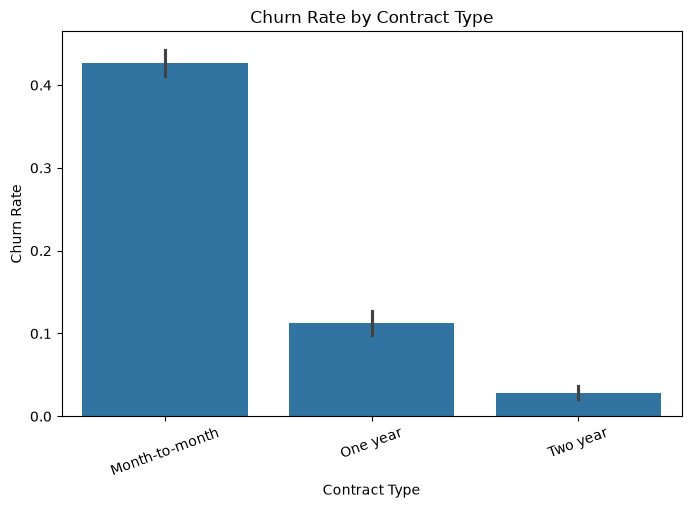

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Contract",
    y="churn_flag"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()

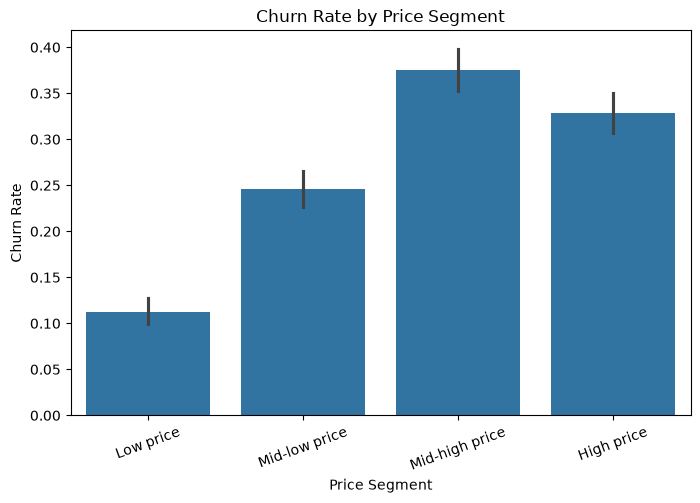

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="price_segment",
    y="churn_flag"
)

plt.title("Churn Rate by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()

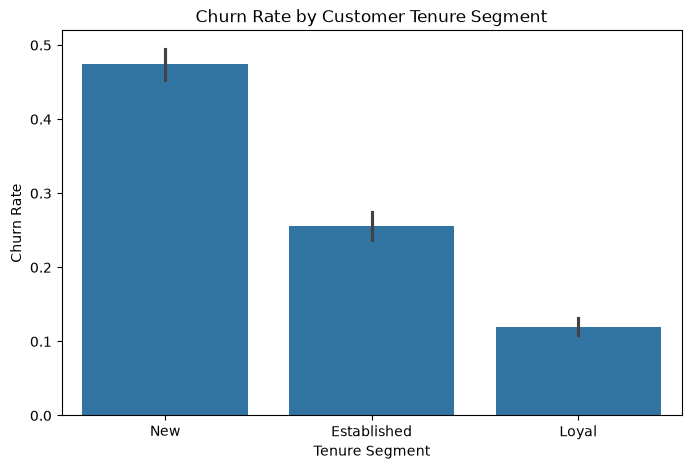

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="tenure_segment",
    y="churn_flag"
)

plt.title("Churn Rate by Customer Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate")
plt.show()

## Initial Business Insights

- Customers with month-to-month contracts show higher churn risk compared to customers with one-year or two-year contracts.
- New customers have higher churn risk than loyal customers.
- Price sensitivity appears to vary by customer segment, suggesting that a uniform price increase strategy may not be optimal.
- The next step is to train a churn prediction model and simulate different price increase scenarios.

In [39]:
segment_summary = (
    df
    .groupby(["Contract", "tenure_segment", "price_segment"], observed=True)
    .agg(
        customers=("customerID", "count"),
        avg_monthly_charge=("MonthlyCharges", "mean"),
        churn_rate=("churn_flag", "mean"),
        avg_tenure=("tenure", "mean")
    )
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)

segment_summary.head(10)

,Contract,tenure_segment,price_segment,customers,avg_monthly_charge,churn_rate,avg_tenure
3,Month-to-month,New,High price,214,96.569159,0.771028,5.920561
2,Month-to-month,New,Mid-high price,598,79.208110,0.673913,4.787625
7,Month-to-month,Established,High price,339,97.652065,0.510324,24.256637
1,Month-to-month,New,Mid-low price,664,54.906928,0.454819,4.182229
6,Month-to-month,Established,Mid-high price,405,81.189012,0.427160,22.624691
11,Month-to-month,Loyal,High price,317,100.343691,0.365931,51.744479
15,One year,New,High price,6,96.691667,0.333333,9.000000
0,Month-to-month,New,Low price,518,22.386197,0.297297,3.891892
10,Month-to-month,Loyal,Mid-high price,170,81.807941,0.288235,49.676471
19,One year,Established,High price,55,99.087273,0.236364,27.927273


In [40]:
segment_summary.to_csv("../outputs/segment_summary.csv", index=False)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "Dependents",
    "Partner"
]

target = "churn_flag"

X = df[features]
y = df[target]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "Dependents",
    "Partner"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

churn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

churn_model.fit(X_train, y_train)

y_pred_proba = churn_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

print("ROC AUC:", round(auc, 3))
print(classification_report(y_test, y_pred))

ROC AUC: 0.838
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [42]:
scenarios = [0.00, 0.03, 0.05, 0.08, 0.10, 0.15]

simulation_results = []

for increase in scenarios:
    temp = df.copy()
    
    temp["price_increase_pct"] = increase
    temp["simulated_monthly_charge"] = temp["MonthlyCharges"] * (1 + increase)
    
    X_sim = temp[features].copy()
    X_sim["MonthlyCharges"] = temp["simulated_monthly_charge"]
    
    temp["predicted_churn_risk"] = churn_model.predict_proba(X_sim)[:, 1]
    temp["expected_retention_probability"] = 1 - temp["predicted_churn_risk"]
    
    temp["expected_revenue"] = (
        temp["simulated_monthly_charge"] *
        temp["expected_retention_probability"]
    )
    
    simulation_results.append({
        "price_increase_pct": increase,
        "avg_churn_risk": temp["predicted_churn_risk"].mean(),
        "avg_retention_probability": temp["expected_retention_probability"].mean(),
        "expected_total_revenue": temp["expected_revenue"].sum(),
        "high_risk_customers": (temp["predicted_churn_risk"] >= 0.60).sum()
    })

scenario_df = pd.DataFrame(simulation_results)

scenario_df

,price_increase_pct,avg_churn_risk,avg_retention_probability,expected_total_revenue,high_risk_customers
0,0.00,0.265935,0.734065,316162.216777,982
1,0.03,0.267560,0.732440,324687.254478,1010
2,0.05,0.268645,0.731355,330338.415314,1024
3,0.08,0.270275,0.729725,338766.761248,1039
4,0.10,0.271364,0.728636,344353.339009,1049
5,0.15,0.274090,0.725910,358206.395335,1078


In [43]:
scenario_df["price_increase_pct_label"] = scenario_df["price_increase_pct"].apply(lambda x: f"{x:.0%}")
scenario_df["avg_churn_risk_label"] = scenario_df["avg_churn_risk"].apply(lambda x: f"{x:.1%}")
scenario_df["avg_retention_probability_label"] = scenario_df["avg_retention_probability"].apply(lambda x: f"{x:.1%}")
scenario_df["expected_total_revenue_label"] = scenario_df["expected_total_revenue"].apply(lambda x: f"${x:,.0f}")

scenario_df[[
    "price_increase_pct_label",
    "avg_churn_risk_label",
    "avg_retention_probability_label",
    "expected_total_revenue_label",
    "high_risk_customers"
]]

,price_increase_pct_label,avg_churn_risk_label,avg_retention_probability_label,expected_total_revenue_label,high_risk_customers
0,0%,26.6%,73.4%,"$316,162",982
1,3%,26.8%,73.2%,"$324,687",1010
2,5%,26.9%,73.1%,"$330,338",1024
3,8%,27.0%,73.0%,"$338,767",1039
4,10%,27.1%,72.9%,"$344,353",1049
5,15%,27.4%,72.6%,"$358,206",1078


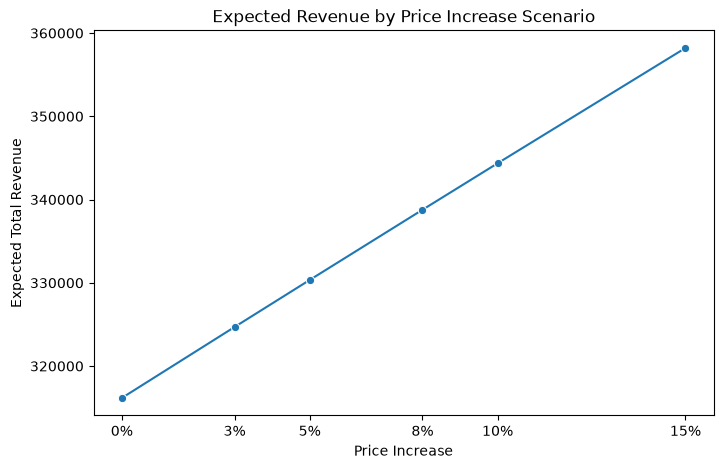

In [44]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=scenario_df,
    x="price_increase_pct",
    y="expected_total_revenue",
    marker="o"
)

plt.title("Expected Revenue by Price Increase Scenario")
plt.xlabel("Price Increase")
plt.ylabel("Expected Total Revenue")
plt.xticks(scenario_df["price_increase_pct"], scenario_df["price_increase_pct_label"])
plt.show()

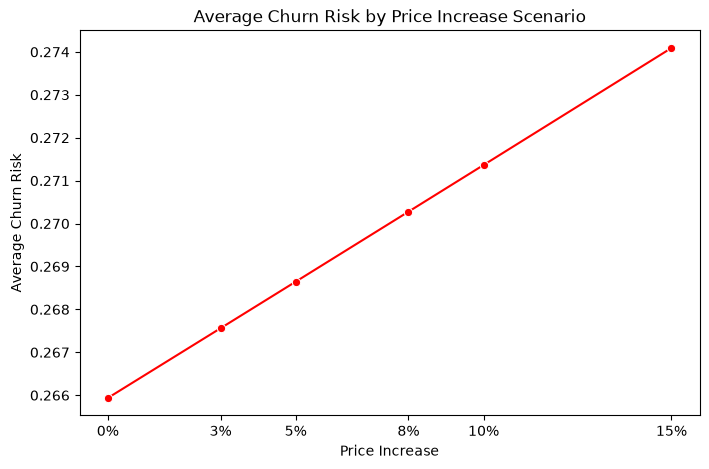

In [45]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=scenario_df,
    x="price_increase_pct",
    y="avg_churn_risk",
    marker="o",
    color="red"
)

plt.title("Average Churn Risk by Price Increase Scenario")
plt.xlabel("Price Increase")
plt.ylabel("Average Churn Risk")
plt.xticks(scenario_df["price_increase_pct"], scenario_df["price_increase_pct_label"])
plt.show()

In [46]:
scenario_df.to_csv("../outputs/scenario_simulation.csv", index=False)

In [47]:
segment_outputs = []

for increase in scenarios:
    temp = df.copy()
    
    temp["price_increase_pct"] = increase
    temp["simulated_monthly_charge"] = temp["MonthlyCharges"] * (1 + increase)
    
    X_sim = temp[features].copy()
    X_sim["MonthlyCharges"] = temp["simulated_monthly_charge"]
    
    temp["predicted_churn_risk"] = churn_model.predict_proba(X_sim)[:, 1]
    temp["expected_retention_probability"] = 1 - temp["predicted_churn_risk"]
    
    temp["expected_revenue"] = (
        temp["simulated_monthly_charge"] *
        temp["expected_retention_probability"]
    )
    
    summary = (
        temp
        .groupby(["Contract", "tenure_segment", "price_segment", "InternetService"], observed=True)
        .agg(
            customers=("customerID", "count"),
            avg_churn_risk=("predicted_churn_risk", "mean"),
            avg_monthly_charge=("simulated_monthly_charge", "mean"),
            expected_revenue=("expected_revenue", "sum")
        )
        .reset_index()
    )
    
    summary["price_increase_pct"] = increase
    segment_outputs.append(summary)

segment_df = pd.concat(segment_outputs, ignore_index=True)

segment_df.head()

,Contract,tenure_segment,price_segment,InternetService,customers,avg_churn_risk,avg_monthly_charge,expected_revenue,price_increase_pct
0,Month-to-month,New,Low price,DSL,130,0.399368,28.710769,2257.272562,0.0
1,Month-to-month,New,Low price,No,388,0.192389,20.267139,6350.121625,0.0
2,Month-to-month,New,Mid-low price,DSL,537,0.414168,51.396927,16253.809069,0.0
3,Month-to-month,New,Mid-low price,Fiber optic,127,0.687182,69.748425,2770.922202,0.0
4,Month-to-month,New,Mid-high price,DSL,23,0.375597,74.223913,1065.471326,0.0


In [48]:
def pricing_recommendation(row):
    if row["avg_churn_risk"] < 0.25:
        return "Apply increase"
    elif row["avg_churn_risk"] < 0.40:
        return "Test with control group"
    else:
        return "Avoid increase"

segment_df["recommendation"] = segment_df.apply(pricing_recommendation, axis=1)

segment_df.head()

,Contract,tenure_segment,price_segment,InternetService,customers,avg_churn_risk,avg_monthly_charge,expected_revenue,price_increase_pct,recommendation
0,Month-to-month,New,Low price,DSL,130,0.399368,28.710769,2257.272562,0.0,Test with control group
1,Month-to-month,New,Low price,No,388,0.192389,20.267139,6350.121625,0.0,Apply increase
2,Month-to-month,New,Mid-low price,DSL,537,0.414168,51.396927,16253.809069,0.0,Avoid increase
3,Month-to-month,New,Mid-low price,Fiber optic,127,0.687182,69.748425,2770.922202,0.0,Avoid increase
4,Month-to-month,New,Mid-high price,DSL,23,0.375597,74.223913,1065.471326,0.0,Test with control group


In [49]:
recommended_segments = (
    segment_df
    .query("recommendation == 'Apply increase' and customers >= 20")
    .sort_values(["price_increase_pct", "expected_revenue"], ascending=[False, False])
)

recommended_segments.head(10)

,Contract,tenure_segment,price_segment,InternetService,customers,avg_churn_risk,avg_monthly_charge,expected_revenue,price_increase_pct,recommendation
359,Two year,Loyal,High price,Fiber optic,386,0.074465,122.430907,43752.301201,0.15,Apply increase
340,One year,Loyal,High price,Fiber optic,383,0.190629,117.867644,36546.598928,0.15,Apply increase
356,Two year,Loyal,Mid-high price,DSL,270,0.020849,93.287361,24662.690003,0.15,Apply increase
354,Two year,Loyal,Mid-low price,DSL,244,0.015015,66.640850,16013.424778,0.15,Apply increase
336,One year,Loyal,Mid-low price,DSL,204,0.048893,65.606373,12719.115343,0.15,Apply increase
353,Two year,Loyal,Low price,No,463,0.005467,25.248337,11626.447711,0.15,Apply increase
337,One year,Loyal,Mid-high price,DSL,108,0.059630,88.716644,9007.952067,0.15,Apply increase
329,One year,Established,Mid-low price,DSL,139,0.114236,64.340432,7919.111111,0.15,Apply increase
301,Month-to-month,New,Low price,No,388,0.194969,23.307210,7279.212148,0.15,Apply increase
316,Month-to-month,Loyal,Mid-low price,DSL,131,0.129238,61.302901,6994.020991,0.15,Apply increase


In [50]:
segment_df.to_csv("../outputs/segment_recommendations.csv", index=False)
recommended_segments.to_csv("../outputs/top_recommended_segments.csv", index=False)

## Executive Summary

This project simulated price increase scenarios from 0% to 15% using a churn prediction model.

Key findings:

- Price increases should not be applied uniformly across the customer base.
- Customers with longer tenure and long-term contracts show lower churn risk under simulated price increases.
- Month-to-month customers and newer customers represent higher-risk segments.
- The recommended strategy is to apply higher increases only to low-risk customer segments and test moderate increases with a control group for medium-risk segments.
- High-risk customers should receive retention actions before any price increase.

In [51]:
scenario_df

,price_increase_pct,avg_churn_risk,avg_retention_probability,expected_total_revenue,high_risk_customers,price_increase_pct_label,avg_churn_risk_label,avg_retention_probability_label,expected_total_revenue_label
0,0.00,0.265935,0.734065,316162.216777,982,0%,26.6%,73.4%,"$316,162"
1,0.03,0.267560,0.732440,324687.254478,1010,3%,26.8%,73.2%,"$324,687"
2,0.05,0.268645,0.731355,330338.415314,1024,5%,26.9%,73.1%,"$330,338"
3,0.08,0.270275,0.729725,338766.761248,1039,8%,27.0%,73.0%,"$338,767"
4,0.10,0.271364,0.728636,344353.339009,1049,10%,27.1%,72.9%,"$344,353"
5,0.15,0.274090,0.725910,358206.395335,1078,15%,27.4%,72.6%,"$358,206"


## Scenario Simulation Insights

The simulation shows how expected revenue and churn risk change under different price increase scenarios.

The goal is not simply to choose the highest price increase, but to identify the scenario with the best balance between revenue growth and retention risk.

In [52]:
best_scenario = scenario_df.sort_values(
    "expected_total_revenue",
    ascending=False
).head(1)

best_scenario

,price_increase_pct,avg_churn_risk,avg_retention_probability,expected_total_revenue,high_risk_customers,price_increase_pct_label,avg_churn_risk_label,avg_retention_probability_label,expected_total_revenue_label
5,0.15,0.27409,0.72591,358206.395335,1078,15%,27.4%,72.6%,"$358,206"


In [53]:
best_increase = best_scenario["price_increase_pct"].iloc[0]
best_revenue = best_scenario["expected_total_revenue"].iloc[0]
best_churn_risk = best_scenario["avg_churn_risk"].iloc[0]

print(f"Best simulated price increase: {best_increase:.0%}")
print(f"Expected total revenue: ${best_revenue:,.0f}")
print(f"Average churn risk: {best_churn_risk:.1%}")

Best simulated price increase: 15%
Expected total revenue: $358,206
Average churn risk: 27.4%


In [54]:
business_summary = scenario_df[[
    "price_increase_pct",
    "avg_churn_risk",
    "avg_retention_probability",
    "expected_total_revenue",
    "high_risk_customers"
]].copy()

business_summary["price_increase_pct"] = business_summary["price_increase_pct"].apply(lambda x: f"{x:.0%}")
business_summary["avg_churn_risk"] = business_summary["avg_churn_risk"].apply(lambda x: f"{x:.1%}")
business_summary["avg_retention_probability"] = business_summary["avg_retention_probability"].apply(lambda x: f"{x:.1%}")
business_summary["expected_total_revenue"] = business_summary["expected_total_revenue"].apply(lambda x: f"${x:,.0f}")

business_summary

,price_increase_pct,avg_churn_risk,avg_retention_probability,expected_total_revenue,high_risk_customers
0,0%,26.6%,73.4%,"$316,162",982
1,3%,26.8%,73.2%,"$324,687",1010
2,5%,26.9%,73.1%,"$330,338",1024
3,8%,27.0%,73.0%,"$338,767",1039
4,10%,27.1%,72.9%,"$344,353",1049
5,15%,27.4%,72.6%,"$358,206",1078


In [55]:
recommended_segments.head(10)

,Contract,tenure_segment,price_segment,InternetService,customers,avg_churn_risk,avg_monthly_charge,expected_revenue,price_increase_pct,recommendation
359,Two year,Loyal,High price,Fiber optic,386,0.074465,122.430907,43752.301201,0.15,Apply increase
340,One year,Loyal,High price,Fiber optic,383,0.190629,117.867644,36546.598928,0.15,Apply increase
356,Two year,Loyal,Mid-high price,DSL,270,0.020849,93.287361,24662.690003,0.15,Apply increase
354,Two year,Loyal,Mid-low price,DSL,244,0.015015,66.640850,16013.424778,0.15,Apply increase
336,One year,Loyal,Mid-low price,DSL,204,0.048893,65.606373,12719.115343,0.15,Apply increase
353,Two year,Loyal,Low price,No,463,0.005467,25.248337,11626.447711,0.15,Apply increase
337,One year,Loyal,Mid-high price,DSL,108,0.059630,88.716644,9007.952067,0.15,Apply increase
329,One year,Established,Mid-low price,DSL,139,0.114236,64.340432,7919.111111,0.15,Apply increase
301,Month-to-month,New,Low price,No,388,0.194969,23.307210,7279.212148,0.15,Apply increase
316,Month-to-month,Loyal,Mid-low price,DSL,131,0.129238,61.302901,6994.020991,0.15,Apply increase


In [56]:
top_segments_clean = recommended_segments[[
    "Contract",
    "tenure_segment",
    "price_segment",
    "InternetService",
    "customers",
    "price_increase_pct",
    "avg_churn_risk",
    "expected_revenue",
    "recommendation"
]].copy()

top_segments_clean["price_increase_pct"] = top_segments_clean["price_increase_pct"].apply(lambda x: f"{x:.0%}")
top_segments_clean["avg_churn_risk"] = top_segments_clean["avg_churn_risk"].apply(lambda x: f"{x:.1%}")
top_segments_clean["expected_revenue"] = top_segments_clean["expected_revenue"].apply(lambda x: f"${x:,.0f}")

top_segments_clean.head(10)

,Contract,tenure_segment,price_segment,InternetService,customers,price_increase_pct,avg_churn_risk,expected_revenue,recommendation
359,Two year,Loyal,High price,Fiber optic,386,15%,7.4%,"$43,752",Apply increase
340,One year,Loyal,High price,Fiber optic,383,15%,19.1%,"$36,547",Apply increase
356,Two year,Loyal,Mid-high price,DSL,270,15%,2.1%,"$24,663",Apply increase
354,Two year,Loyal,Mid-low price,DSL,244,15%,1.5%,"$16,013",Apply increase
336,One year,Loyal,Mid-low price,DSL,204,15%,4.9%,"$12,719",Apply increase
353,Two year,Loyal,Low price,No,463,15%,0.5%,"$11,626",Apply increase
337,One year,Loyal,Mid-high price,DSL,108,15%,6.0%,"$9,008",Apply increase
329,One year,Established,Mid-low price,DSL,139,15%,11.4%,"$7,919",Apply increase
301,Month-to-month,New,Low price,No,388,15%,19.5%,"$7,279",Apply increase
316,Month-to-month,Loyal,Mid-low price,DSL,131,15%,12.9%,"$6,994",Apply increase


## Executive Recommendation

The analysis suggests that price increases should be applied selectively rather than uniformly across the customer base.

Customers with longer tenure and long-term contracts show lower churn risk and are better candidates for moderate or high price increases. In contrast, month-to-month and newer customers show higher churn risk and should be excluded from aggressive price increases.

The recommended strategy is:

- Apply price increases to low-risk loyal segments.
- Test moderate increases with a control group for medium-risk segments.
- Avoid price increases for high-risk customers.
- Use retention campaigns before pricing actions in sensitive segments.